# Assignment 2 - Image Classification and CNN

### Tevyn Vergara | 46421201 | Electrical & Biomedical Engineer

DISCLAIMER: Google Gemini 3 was used for this assignment for:
1. Layout tips (all questions)
2. Syntax checking (all questions)
3. Trouble shooting and debugging
4. Functionality tips and suggestions (all questions)
5. Tips and explanation for key functions/theories and purposes
6. Re-organizing to look more modular and readable

References:
1. Google. (2026, March 17). Methods of providing alterative text for accessibility on websites. [Generative AI chat]. Gemini 3. https://gemini.google.com/


## Standard Imports for Assignment 2 ##

Please run this before executing any other cell

In [4]:
import numpy as np
import pickle   
import matplotlib.pyplot as plt
import skimage
import sys
import time
from skimage.feature import hog
from skimage.color import rgb2gray
print('numpy', np.__version__)
print('matplotlib', plt.matplotlib.__version__)
print('skimage', skimage.__version__)
print('sys', sys.version)
print('pickle', pickle.format_version)
print(time.ctime())

numpy 2.4.4
matplotlib 3.10.8
skimage 0.26.0
sys 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
pickle 4.0
Thu Apr 16 17:43:24 2026


## NOTE: Code was ran locally as I have a dedicated GPU ##

## Question "0" - CIFAR-10 Dataset ##

Here, I'm attempting to load the images. The formatting is currently:

- Labels in batches.meta [0-9] with their respective image classes:
    0: Aeroplane
    1: Automobile
    2: Bird
    3: Cat
    4: Deer
    5: Dog
    6: Frog
    7: Horse
    8: Ship
    9: Truck

- 3072 features of flattened information --> 32 x 32 pixel images with 3 RGB channels 

- 50,000 training images split into x5 data_batch_x files (5 in total). Format: shape(10,000, 3072). So 10,000 images per batch of 3072 flattened information

To format for CNN training:
1. Use unpickle() from source: https://www.cs.toronto.edu/~kriz/cifar.html. This returns a batch dictionary of the 10,000 images, their labels, and each of their single channel information of (32x32 | 3 RGB). Their is also metadata for the batch such as the image and batch file names (Not needed for project)

2. Unload image class labels from batches.meta (0-9) and convert their byte strings to normal text for readibility. Store in meta.

3. Unload and also combine the 5 batches of training data from data_batch_x where x: [0,5]. Assuming that all the images have the same format of 
(32x32 |3 RGB), append all imagee (with their data) and their respective labels to a dictionary of arrays that contain:
    - Image data (batch[b"data"])
    - Image labels (batch[b"data"])
    - Metadata (filenames, image names) but unused


To ensure that testing data was loaded correctly, loop through the whole "batch" dataset and load the first image of each class. Display it and its respective label.



C:\Users\tevyn\AppData\Local\Temp\ipykernel_36352\1026889439.py:10: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(fo, encoding="bytes")


X_train shape: (50000, 3072)
y_train shape: (50000,)
X_test shape: (10000, 3072)
y_test shape: (10000,)
Label names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


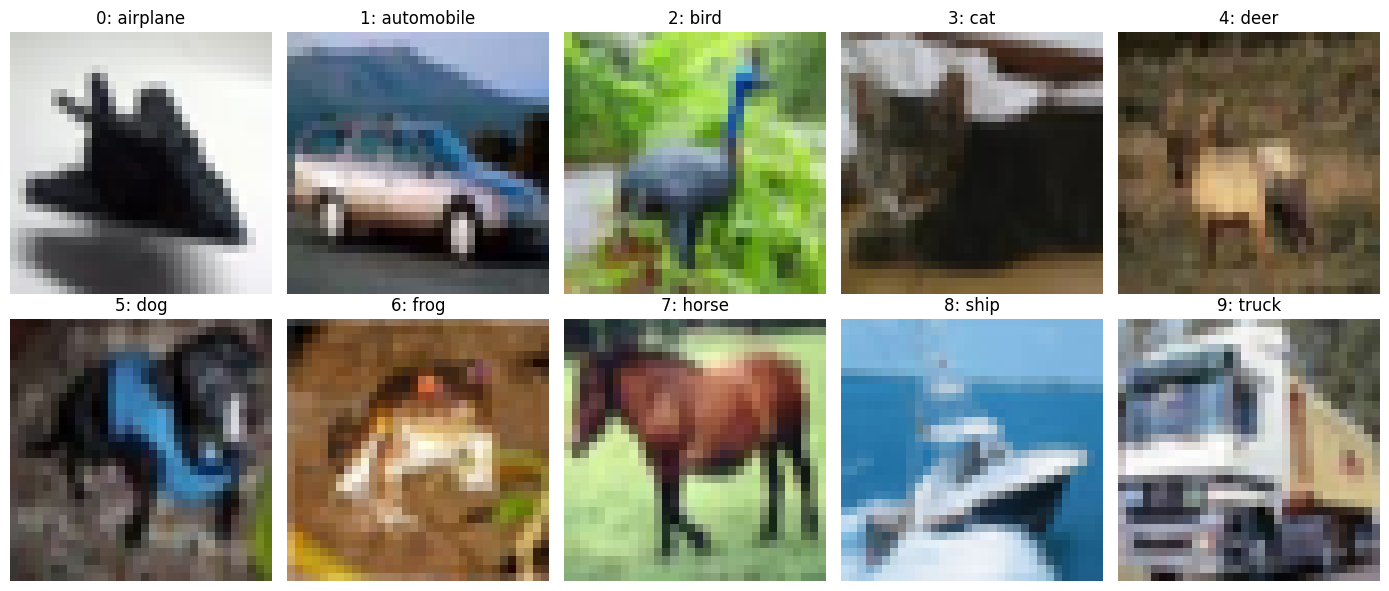

In [5]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


# Utility: read one CIFAR-10 batch/metadata pickle file from disk. From: https://www.cs.toronto.edu/~kriz/cifar.html
def unpickle(file_path):
    with open(file_path, "rb") as fo:
        batch = pickle.load(fo, encoding="bytes")
    return batch

# End-to-end loader for CIFAR-10 in the provided folder structure.
# Returns train/test images + labels, and human-readable class names.
def load_cifar10(data):
    # 1) Load class label names (airplane, automobile, etc.) from metadata.
    meta = unpickle(os.path.join(data, "batches.meta"))
    label_names = [name.decode("utf-8") for name in meta[b"label_names"]]

    # 2) Read and concatenate all 5 training batch files.
    train_images = []
    train_labels = []
    for i in range(1, 6):
        batch = unpickle(os.path.join(data, f"data_batch_{i}"))
        train_images.append(batch[b"data"])
        train_labels.extend(batch[b"labels"])

    # 3) Stack image rows into one array of shape (50000, 3072).
    X_train = np.vstack(train_images)
    y_train = np.array(train_labels, dtype=np.int64)

    # 3) Load test batch
    test_batch = unpickle(os.path.join(data, "test_batch"))
    X_test = test_batch[b"data"]
    y_test = np.array(test_batch[b"labels"], dtype=np.int64)

    return X_train, y_train, X_test, y_test, label_names

# Load the CIFAR-10 Dataset 
data = "cifar-10-batches-py"
X_train, y_train, X_test, y_test, label_names = load_cifar10(data)

# Quick shape sanity check to confirm successful parsing.
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print("Label names:", label_names)

# Visual inspection: show one example image from each class.
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for class_id, ax in enumerate(axes.ravel()):
    # Pick the first training sample for this class index.
    idx = np.where(y_train == class_id)[0][0]
    img = X_train[idx].reshape(3, 32, 32).transpose(1, 2, 0)  # (3072,) -> (32,32,3)
    ax.imshow(img)
    ax.set_title(f"{class_id}: {label_names[class_id]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Extracting features for 50000 images. This may take a moment...
Extracting features for 10000 images. This may take a moment...
Starting Hyperparameter Grid Search...
Epochs   | LR     | Batch  | Final Loss   | Test Acc
-------------------------------------------------------
Starting Training...
Initial Loss (Epoch 1): 1.4210
Final Loss (Epoch 200): 1.3691
200      | 0.1    | 100    | 1.3691       | 49.93%
Starting Training...
Initial Loss (Epoch 1): 1.4238
Final Loss (Epoch 200): 1.3548
200      | 0.1    | 128    | 1.3548       | 51.17%
Starting Training...
Initial Loss (Epoch 1): 1.4288
Final Loss (Epoch 200): 1.3392
200      | 0.1    | 256    | 1.3392       | 51.55%
Starting Training...
Initial Loss (Epoch 1): 1.4481
Final Loss (Epoch 200): 1.3319
200      | 0.1    | 512    | 1.3319       | 51.98%
Starting Training...
Initial Loss (Epoch 1): 1.4698
Final Loss (Epoch 200): 1.4285
200      | 0.2    | 100    | 1.4285       | 48.54%
Starting Training...
Initial Loss (Epoch 1): 1.4452
Fi

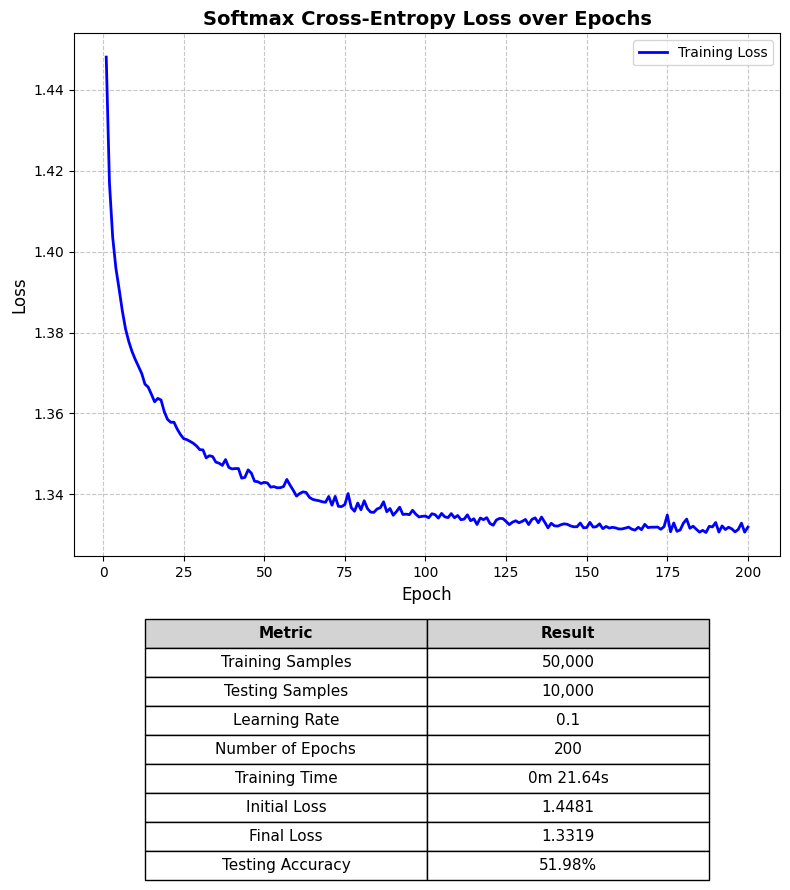

In [6]:
from skimage.feature import local_binary_pattern
from skimage.color import rgb2gray
import numpy as np

# =====================================================================
# 1. DATA PREPARATION & FEATURE EXTRACTION (HOG VERSION)
# =====================================================================

def extract_hog_features(X_raw):
    """
    Converts raw CIFAR-10 pixel arrays into HOG feature vectors.
    """
    num_images = X_raw.shape[0]
    X_reshaped = X_raw.reshape(num_images, 3, 32, 32).transpose(0, 2, 3, 1)
    X_gray = rgb2gray(X_reshaped)
    
    print(f"Extracting features for {num_images} images. This may take a moment...")
    features = []
    for i in range(num_images):
        h = hog(X_gray[i], orientations=9, pixels_per_cell=(8, 8),
                cells_per_block=(2, 2), feature_vector=True)
        features.append(h)
        
    return np.array(features)

def normalize_features(X):
    """
    Standardizes features by removing the mean and scaling to unit variance.
    """
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0) + 1e-8 
    return (X - mean) / std

def to_one_hot(y, num_classes=10):
    """
    Converts integer labels (0-9) into one-hot encoded vectors.
    """
    m = y.shape[0]
    one_hot = np.zeros((m, num_classes))
    one_hot[np.arange(m), y] = 1
    return one_hot

# =====================================================================
# 2. SOFTMAX ALGORITHM FUNCTIONS
# =====================================================================

def softmax(Z):
    """
    Computes the softmax probabilities with numerical stability.
    """
    shifted_Z = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(shifted_Z)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

def compute_loss(Y_true, Y_pred):
    """
    Computes the Categorical Cross-Entropy Loss.
    """
    m = Y_true.shape[0]
    loss = -np.sum(Y_true * np.log(Y_pred + 1e-9)) / m
    return loss

def predict(X, W, b):
    """
    Returns the class with the highest probability.
    """
    Z = np.dot(X, W) + b
    A = softmax(Z)
    return np.argmax(A, axis=1)

# =====================================================================
# 3. TRAINING LOOP
# =====================================================================

# Use batch size of 256 for optimized gradient descent convergence (reduced training time and prevents noise spikes during gradient updates).
def train_softmax(X_train, y_train, num_classes=10, learning_rate=0.1, epochs=100, batch_size=256):
    """
    Trains the Softmax Regression model using Mini-Batch Gradient Descent.
    """
    num_samples, num_features = X_train.shape
    
    W = np.zeros((num_features, num_classes))
    b = np.zeros(num_classes)
    Y_one_hot = to_one_hot(y_train, num_classes)
    loss_history = []
    
    print("Starting Training...")
    start_time = time.time()
    
    for epoch in range(epochs):
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        X_shuffled = X_train[indices]
        Y_shuffled = Y_one_hot[indices]
        
        for i in range(0, num_samples, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            Y_batch = Y_shuffled[i:i + batch_size]
            m_batch = X_batch.shape[0]
            
            Z = np.dot(X_batch, W) + b
            A = softmax(Z)
            
            dZ = A - Y_batch
            dW = (1 / m_batch) * np.dot(X_batch.T, dZ)
            db = (1 / m_batch) * np.sum(dZ, axis=0)
            
            W -= learning_rate * dW
            b -= learning_rate * db
            
        Z_full = np.dot(X_train, W) + b
        A_full = softmax(Z_full)
        current_loss = compute_loss(Y_one_hot, A_full)
        loss_history.append(current_loss)
        
        if epoch == 0:
            print(f"Initial Loss (Epoch 1): {current_loss:.4f}")
        elif epoch == epochs - 1:
            print(f"Final Loss (Epoch {epochs}): {current_loss:.4f}")
            
    end_time = time.time()
    training_time = end_time - start_time
    
    return W, b, loss_history, training_time

# =====================================================================
# 3.5 HYPERPARAMETER OPTIMIZATION GRID SEARCH
# =====================================================================

def optimize_hyperparameters(X_train_norm, y_train, X_test_norm, y_test):
    """
    Runs a grid search over specified Epochs, Learning Rates, and Batch Sizes.
    Returns the weights, biases, and history of the BEST performing model.
    """
    # 1. Epochs (start at 200 and go up by 50)
    epochs_list = [200, 250, 300]
    
    # 2. Learning Rate (go from 0.1 and scale up every 0.1)
    lr_list = [0.1, 0.2, 0.3] 
    
    # 3. Batch size (Start from 100. Then do 128, and then 256 and double it every time)
    batch_sizes = [100, 128, 256, 512]
    
    best_acc = 0
    best_params = {}
    
    # Placeholders to store the best model's variables for plotting
    best_W, best_b, best_loss_history, best_train_time = None, None, None, None
    
    print(f"{'Epochs':<8} | {'LR':<6} | {'Batch':<6} | {'Final Loss':<12} | {'Test Acc'}")
    print("-" * 55)
    
    for e in epochs_list:
        for lr in lr_list:
            for b in batch_sizes:
                # Train the model with current grid parameters
                W, bias, loss_hist, train_time = train_softmax(
                    X_train_norm, y_train, 
                    learning_rate=lr, 
                    epochs=e, 
                    batch_size=b
                )
                
                # Test the model immediately
                y_pred = predict(X_test_norm, W, bias)
                acc = np.mean(y_pred == y_test) * 100
                final_loss = loss_hist[-1]
                
                print(f"{e:<8} | {lr:<6} | {b:<6} | {final_loss:<12.4f} | {acc:.2f}%")
                
                # If this is the best accuracy we've seen, save its data!
                if acc > best_acc:
                    best_acc = acc
                    best_params = {'Epochs': e, 'LR': lr, 'Batch': b}
                    best_W = W.copy()
                    best_b = bias.copy()
                    best_loss_history = loss_hist
                    best_train_time = train_time
                    
    print("\n" + "="*55)
    print("Optimization Complete!")
    print(f"Best Accuracy: {best_acc:.2f}% with parameters: {best_params}")
    print("="*55 + "\n")
    
    # Return the variables needed for the final Plotting & Summary Table
    return best_W, best_b, best_loss_history, best_train_time, best_params, best_acc

# =====================================================================
# 4. EXECUTION PIPELINE (HOG VERSION)
# =====================================================================

# Step A: Extract Features
X_train_features = extract_hog_features(X_train)
X_test_features = extract_hog_features(X_test)

# Step B: Normalize Features
X_train_norm = normalize_features(X_train_features)
X_test_norm = normalize_features(X_test_features)

# Step C: Run Hyperparameter Optimization
print("Starting Hyperparameter Grid Search...")
W, b, loss_history, train_time, best_params, testing_accuracy = optimize_hyperparameters(
    X_train_norm, y_train, 
    X_test_norm, y_test
)

# Step D: Extract the best parameters dynamically so your table prints correctly
epochs = best_params['Epochs']
learning_rate = best_params['LR']
batch_size = best_params['Batch']

# =====================================================================
# 5. RESULTS SUMMARY & PLOTTING
# =====================================================================

# Format training time into minutes and seconds
time_mins = int(train_time // 60)
time_secs = train_time % 60
time_str = f"{time_mins}m {time_secs:.2f}s"

# Data for the Matplotlib table
table_data = [
    ["Training Samples", f"{X_train.shape[0]:,}"],
    ["Testing Samples", f"{X_test.shape[0]:,}"],
    ["Learning Rate", f"{learning_rate}"],
    ["Number of Epochs", f"{epochs}"],
    ["Training Time", time_str],
    ["Initial Loss", f"{loss_history[0]:.4f}"],
    ["Final Loss", f"{loss_history[-1]:.4f}"],
    ["Testing Accuracy", f"{testing_accuracy:.2f}%"]
]

# Create a figure with 2 subplots: Top for graph, Bottom for table
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), gridspec_kw={'height_ratios': [3, 1.5]})

# --- Subplot 1: The Loss Graph ---
ax1.plot(range(1, epochs + 1), loss_history, label='Training Loss', color='blue', linewidth=2)
ax1.set_title("Softmax Cross-Entropy Loss over Epochs", fontsize=14, fontweight='bold')
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# --- Subplot 2: The Results Table ---
ax2.axis('off') # Hide axes for the table
table = ax2.table(cellText=table_data, 
                  colLabels=["Metric", "Result"], 
                  cellLoc='center', 
                  loc='center',
                  bbox=[0.1, 0, 0.8, 1]) # [left, bottom, width, height]

# Make the table visually appealing
table.auto_set_font_size(False)
table.set_fontsize(11)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#d3d3d3')

plt.tight_layout()
plt.show()

In [ ]:
# RESULTS: HOG Feature Extraction Version #

Things to tweak to improve testing accuracy (LBP):
1. Number of epochs: Increasing epochs may allow the model to learn more complex patterns, but watch for overfitting.
2. Learning rate: Adjusting the learning rate can help the model converge better. Too high may cause divergence, too low may slow down training.
3. Batch size: Experimenting with different batch sizes (e.g., 128, 512) can affect convergence and generalization.
4. Feature extraction parameters: Tuning HOG parameters (orientations, pixels_per_cell, cells_per_block) may yield more discriminative features.

Okay so the first time: I have this Flat Loss Curve:

![alt text](image.png)

I chose random parameters such as:

1. Learning Rate: 0.5
2. Epoch Number: 150
3. Batch size: 256

However, it seems that the model itself is not inheritly learning anything and is randomly guessing all 10 image classes. The 12.04% suggests that the model is floating above the 10% random chance baseline (INSERT SOURCE)

NEXT: Insert parameter optimization code
Optimized parameters:
1. Learning Rate: 0.1
2. Epoch Number: 200
3. Batch: 256

Testing Accuracy: 12.85%

Observation: Feature extraction is currently NOT working as the window is set to 4 pixels and a stride of 4.

Don't want to risk doing (2x2) as it will break my softmax function. Risk losing "big picture" shapes and overfit to training data

Attempt: Running it again with 250 EPOCHS and 0.1 Learning Rate

Attempt 2:

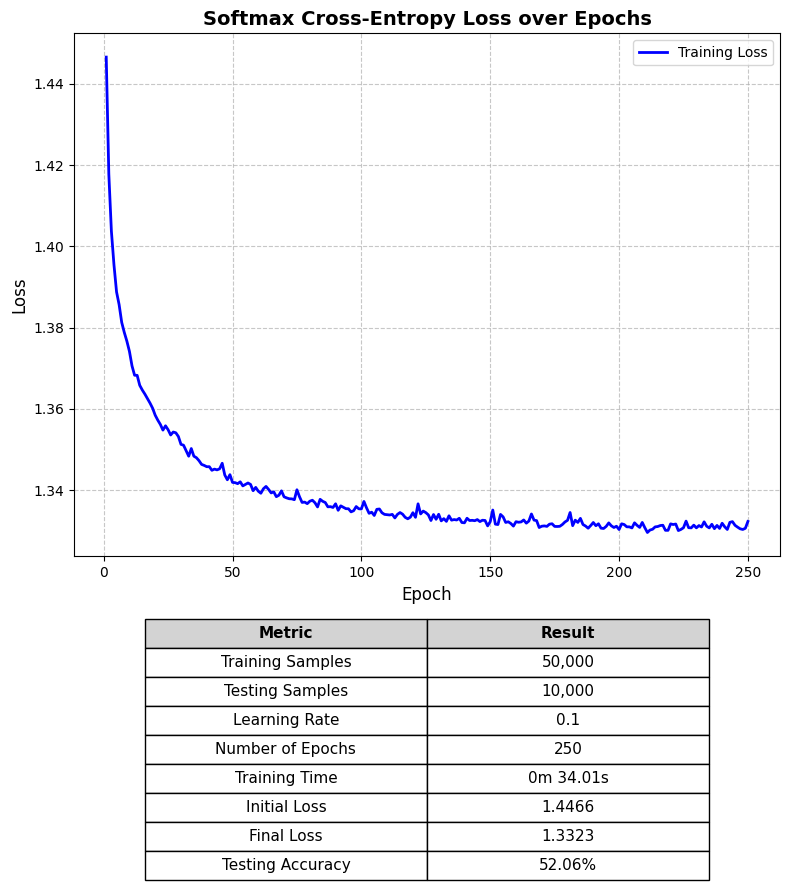